# Farm use case LLM scalability

In [6]:
%cd ..
%pwd  # should be "llm-adaptation"

C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation


C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


'C:\\Users\\micha\\OneDrive - Univerzita Karlova\\research\\2024-LLM-DEECo\\llm-adaptation'

## Run the experiment

In [58]:
import subprocess

def run(llm_config, scale_config):
    configs = ["farm/configs/default.yaml", "farm/configs/config_no_battery.yaml", "farm/configs/scalability/scale.yaml", "configs/jinja.yaml", "DSL/drones.yaml", f"configs/{llm_config}.yaml", "farm/configs/no_battery_llm.yaml", "farm/configs/simulation_description_2.yaml", "farm/configs/strategy_multiple.yaml", "configs/retry2.yaml", f"farm/configs/scalability/{scale_config}.yaml"]
    run = ["python", "main.py", *configs, "-e", "1", "-s", "1"]

    result = subprocess.run(run, capture_output=True)
    stdout = result.stdout.decode("utf-8")
    print(stdout.partition("Simulation done")[2])

    stderr = result.stderr.decode("utf-8")
    if (stderr):
        print(stderr)

### GPT-4o mini

In [59]:
run("llm_gpt4omini", "scale1")


Traceback (most recent call last):
  File "C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation\main.py", line 8, in <module>
    from utils import nested_update, read_configs, Logger, print_config
  File "C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation\utils.py", line 8, in <module>
    from langchain_core.messages import AIMessage
ModuleNotFoundError: No module named 'langchain_core'



## Results

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
results_folder = Path("./logs/no_battery/scale")

WindowsPath('C:/Users/micha/OneDrive - Univerzita Karlova/research/2024-LLM-DEECo/llm-adaptation/logs/no_battery/scale')

In [14]:
results_files = sorted(results_folder.glob("*/*.llm.csv"))
print(len(results_files), "files found")

4 files found


In [21]:
datas = []

In [22]:
for file in results_files:
    try:
        name = file.stem
        if "jinja_" not in name:
            continue

        data = pd.read_csv(file)

        parts = name.split("_")
        llm = parts[2]
        scale = parts[-1].split(".")[0]
        params = parts[3:-1]
        params = ",\n".join(params)

        data["llm"] = llm
        data["scale"] = scale
        data["params"] = params
        datas.append(data)

    except pd.errors.EmptyDataError:
        print("Skipping empty file", file)
    except IndexError:
        print("Index error in file", file)

In [50]:
summary = pd.concat(datas, ignore_index=True)
summary

,step,try,errors,input_tokens,output_tokens,reasoning_tokens,response_time,llm,scale,params
0,1,0,0,1214,457,0,8.698162,sd2,scale1,"strategy,\nretry2"
1,11,0,0,1252,380,0,8.075552,sd2,scale1,"strategy,\nretry2"
2,21,0,0,1250,410,0,7.744268,sd2,scale1,"strategy,\nretry2"
3,31,0,0,1270,558,0,14.144804,sd2,scale1,"strategy,\nretry2"
4,41,0,0,1286,451,0,9.783066,sd2,scale1,"strategy,\nretry2"
...,...,...,...,...,...,...,...,...,...,...
132,211,1,0,33812,2729,0,62.943965,sd2,scale57,"strategyMultiple,\nretry2"
133,221,0,0,30767,3032,0,78.041437,sd2,scale57,"strategyMultiple,\nretry2"
134,231,0,0,30654,3179,0,65.777664,sd2,scale57,"strategyMultiple,\nretry2"
135,241,0,2,30522,3057,0,60.138364,sd2,scale57,"strategyMultiple,\nretry2"


In [51]:
summary['scale'] = summary['scale'].map({
    "scale1": 1,
    "scale10": 5,
    "scale20": 10,
    "scale57": 25,
    "scale116": 50,
    "scale206": 90,
})

In [52]:
summary.to_csv(results_folder / "summary.csv", index=False)

In [53]:
initial = summary[summary["try"] == 0]
initial

,step,try,errors,input_tokens,output_tokens,reasoning_tokens,response_time,llm,scale,params
0,1,0,0,1214,457,0,8.698162,sd2,1,"strategy,\nretry2"
1,11,0,0,1252,380,0,8.075552,sd2,1,"strategy,\nretry2"
2,21,0,0,1250,410,0,7.744268,sd2,1,"strategy,\nretry2"
3,31,0,0,1270,558,0,14.144804,sd2,1,"strategy,\nretry2"
4,41,0,0,1286,451,0,9.783066,sd2,1,"strategy,\nretry2"
...,...,...,...,...,...,...,...,...,...,...
129,201,0,1,30626,1895,0,47.998967,sd2,25,"strategyMultiple,\nretry2"
131,211,0,2,30667,3075,0,73.720355,sd2,25,"strategyMultiple,\nretry2"
133,221,0,0,30767,3032,0,78.041437,sd2,25,"strategyMultiple,\nretry2"
134,231,0,0,30654,3179,0,65.777664,sd2,25,"strategyMultiple,\nretry2"


### Errors

In [54]:
repeated = pd.DataFrame(columns=["llm", "scale", "try", "error_count"])
for llm in summary["llm"].unique():
    for scale in summary["scale"].unique():
        for retry in (1, 2):
            count = len(summary[(summary["llm"] == llm) & (summary["scale"] == scale) & (summary["try"] == retry)])
            repeated.loc[len(repeated)] = [llm, scale, retry, count]
repeated

,llm,scale,try,error_count
0,sd2,1,1,0
1,sd2,1,2,0
2,sd2,5,1,2
3,sd2,5,2,1
4,sd2,10,1,6
5,sd2,10,2,1
6,sd2,25,1,11
7,sd2,25,2,1


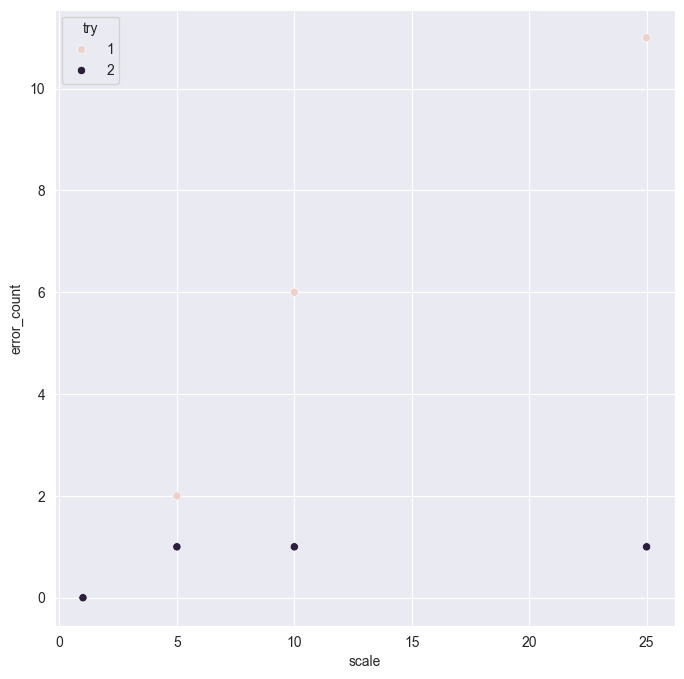

In [55]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x="scale", y="error_count", hue="try", data=repeated, ax=ax)
plt.show()

### Time

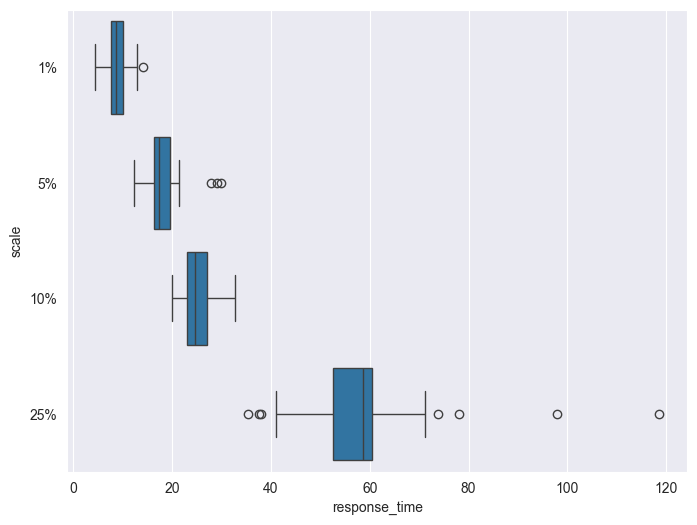

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="response_time", y="scale", data=initial, ax=ax)
plt.show()

### Input tokens

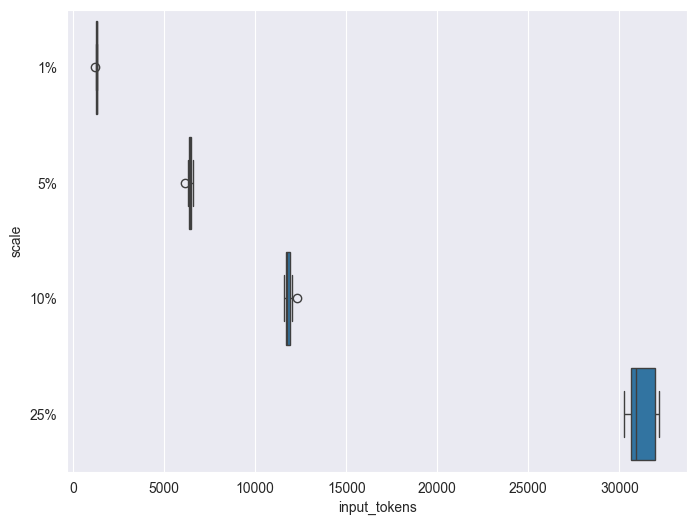

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="input_tokens", y="scale", data=initial, ax=ax)
plt.show()

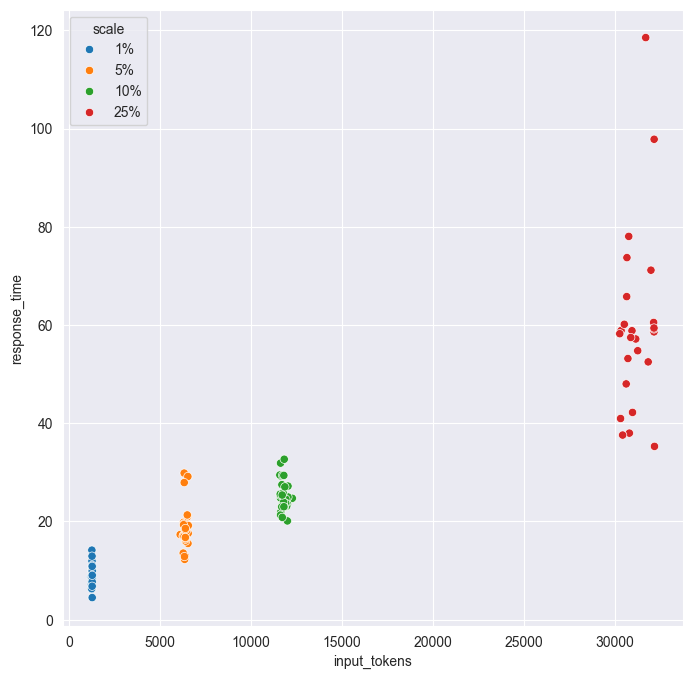

In [33]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x="input_tokens", y="response_time", hue="scale", data=initial, ax=ax)
plt.show()

### Output tokens

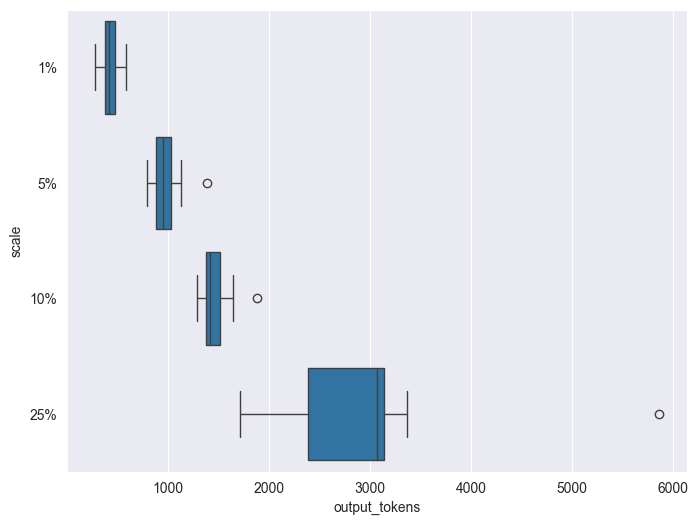

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="output_tokens", y="scale", data=initial, ax=ax)
plt.show()

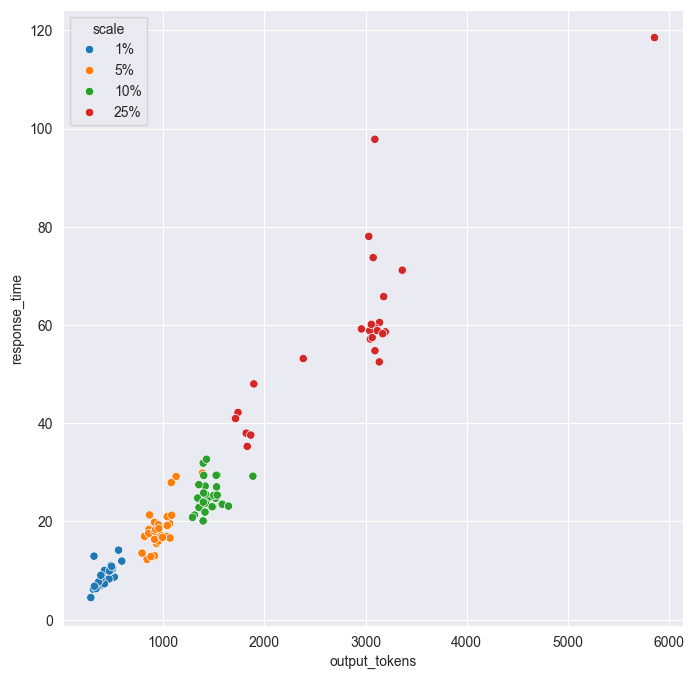

In [34]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x="output_tokens", y="response_time", hue="scale", data=initial, ax=ax)
plt.show()

### Cost